# **Flight Ticket Price Prediction Project**

In [ ]:
# ==========================
# Data Manipulation
# ==========================
import pandas as pd
import numpy as np

# ==========================
# Data Visualization
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Improve plot size
plt.rcParams["figure.figsize"] = (8,5)
sns.set_style("whitegrid")

In [ ]:
df = pd.read_csv("/content/flight_dataset.csv")

In [ ]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
df.tail()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [ ]:
df.shape

(300153, 11)

In [ ]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [ ]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [ ]:
df.describe(include = "object")

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


In [ ]:
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [ ]:
(df.isnull().sum()/len(df))*100

,0
airline,0.0
flight,0.0
source_city,0.0
departure_time,0.0
stops,0.0
arrival_time,0.0
destination_city,0.0
class,0.0
duration,0.0
days_left,0.0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(300153, 11)

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns

numerical_cols = df.select_dtypes(exclude="object").columns

print("Categorical Features:")
print(categorical_cols)

print()

print("Numerical Features:")
print(numerical_cols)

Categorical Features:
Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='object')

Numerical Features:
Index(['duration', 'days_left', 'price'], dtype='object')


In [ ]:
for col in categorical_cols:
    print("="*40)
    print(col)
    print(df[col].unique())

airline
['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
flight
['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433']
source_city
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
departure_time
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
stops
['zero' 'one' 'two_or_more']
arrival_time
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
destination_city
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
class
['Economy' 'Business']


In [ ]:
for col in categorical_cols:
    print(col,":",df[col].nunique())

airline : 6
flight : 1561
source_city : 6
departure_time : 6
stops : 3
arrival_time : 6
destination_city : 6
class : 2


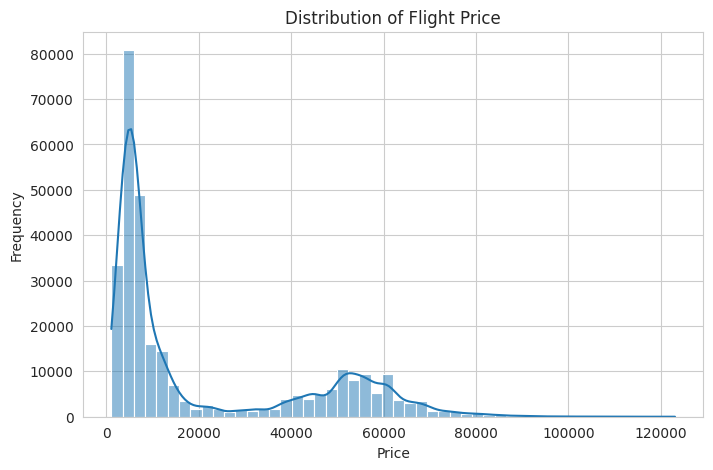

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=50, kde=True)

plt.title("Distribution of Flight Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

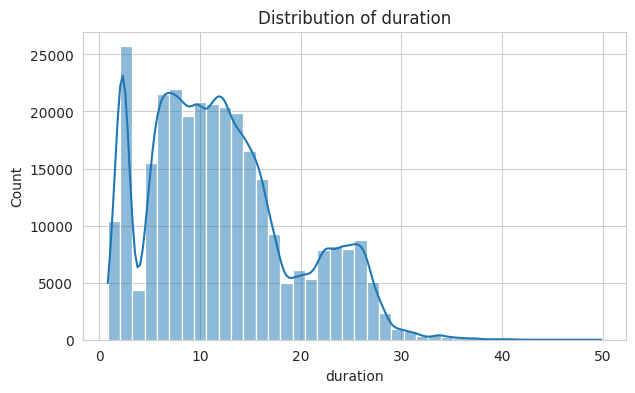

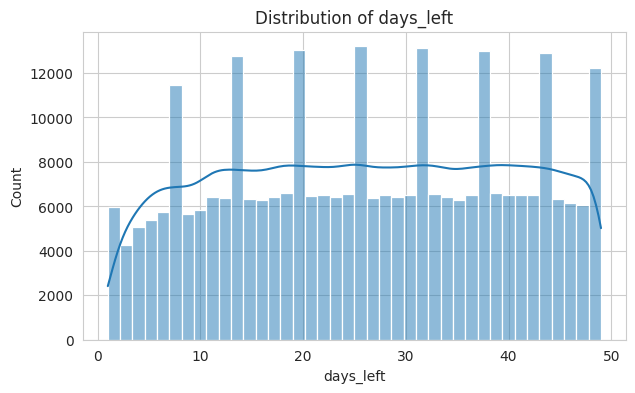

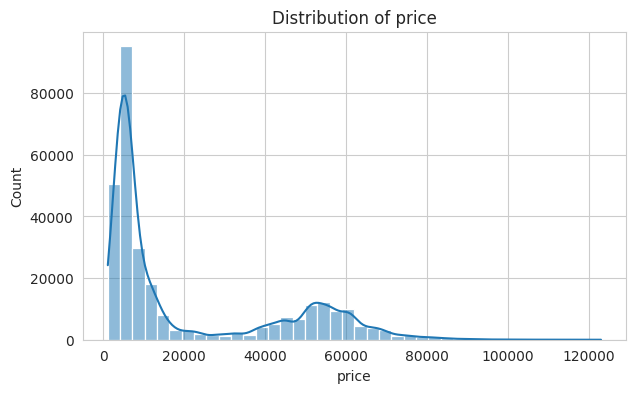

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(7,4))

    sns.histplot(df[col], bins=40, kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

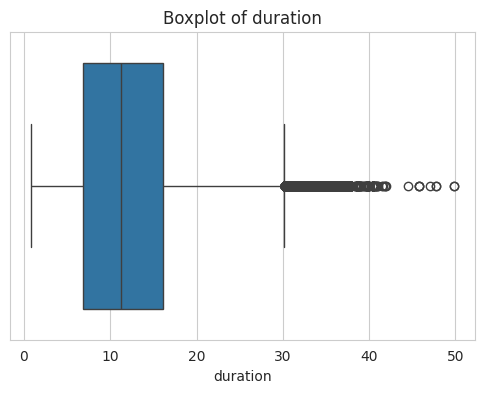

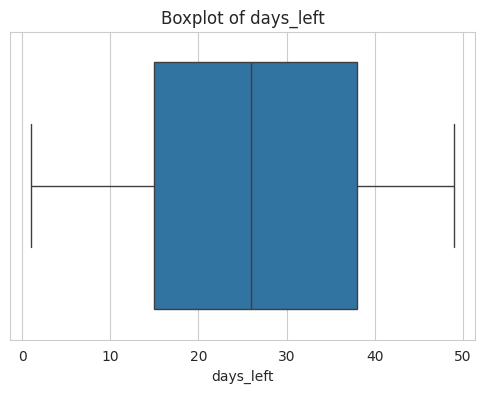

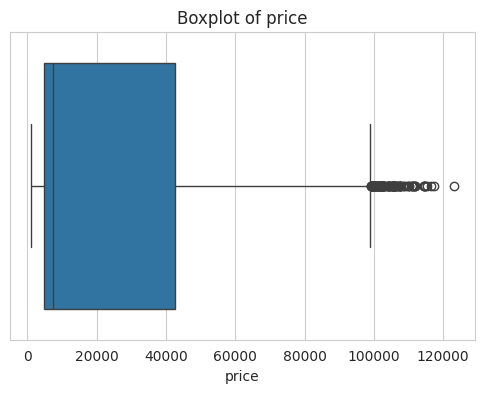

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

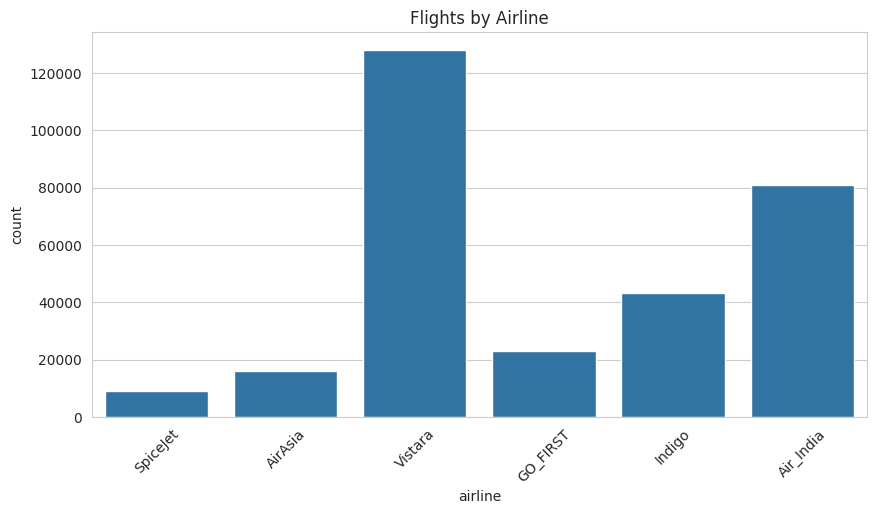

In [ ]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="airline")

plt.xticks(rotation=45)

plt.title("Flights by Airline")

plt.show()

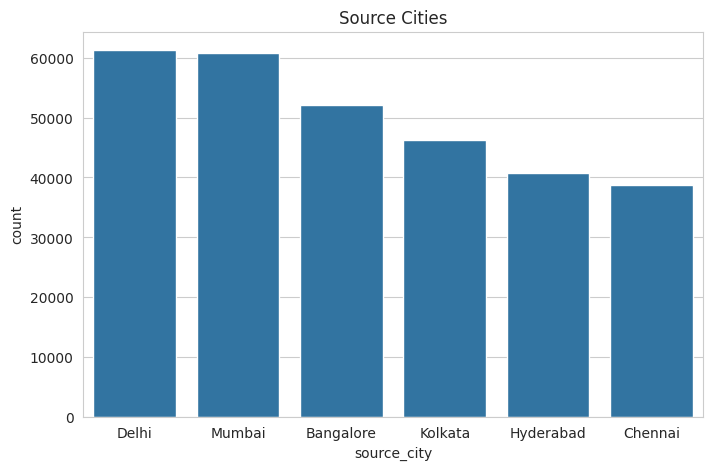

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="source_city")

plt.title("Source Cities")

plt.show()

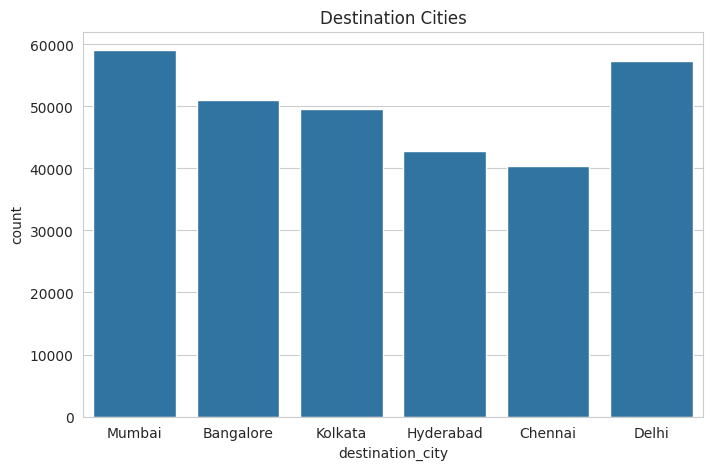

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="destination_city")

plt.title("Destination Cities")

plt.show()

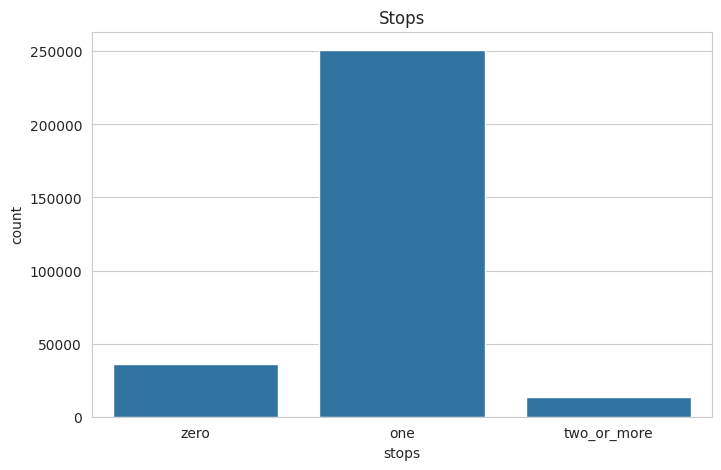

In [ ]:
sns.countplot(data=df, x="stops")

plt.title("Stops")

plt.show()

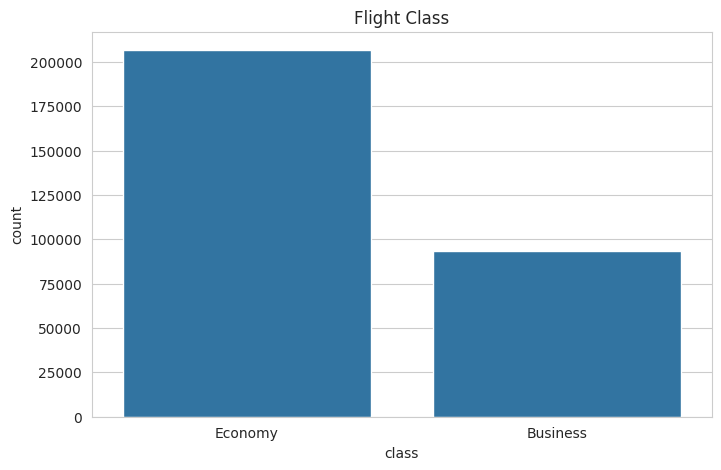

In [ ]:
sns.countplot(data=df, x="class")

plt.title("Flight Class")

plt.show()

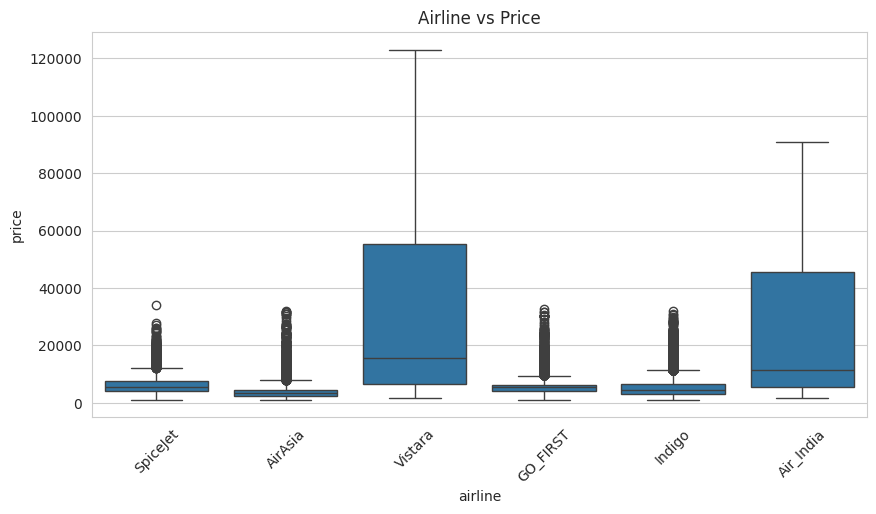

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="airline",
    y="price"
)

plt.xticks(rotation=45)

plt.title("Airline vs Price")

plt.show()

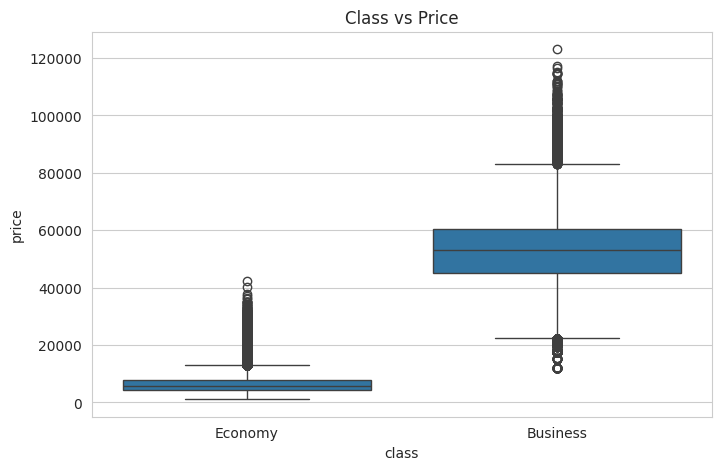

In [ ]:
sns.boxplot(
    data=df,
    x="class",
    y="price"
)

plt.title("Class vs Price")

plt.show()

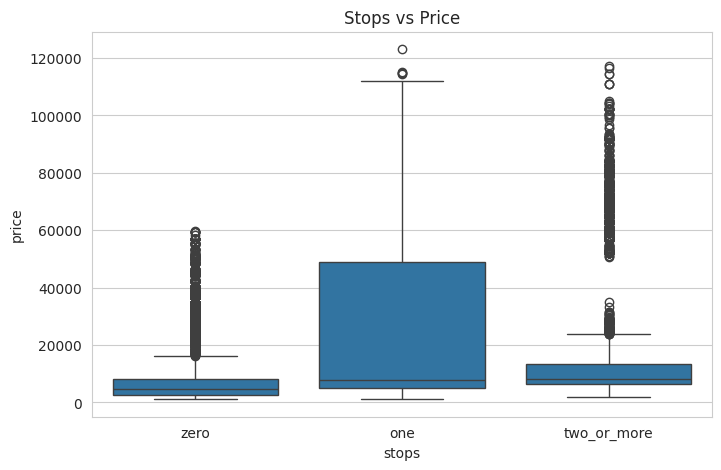

In [ ]:
sns.boxplot(
    data=df,
    x="stops",
    y="price"
)

plt.title("Stops vs Price")

plt.show()

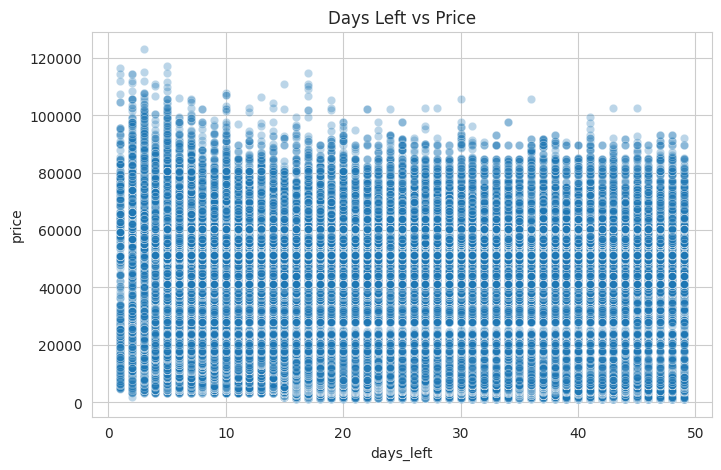

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="days_left",
    y="price",
    alpha=0.3
)

plt.title("Days Left vs Price")

plt.show()

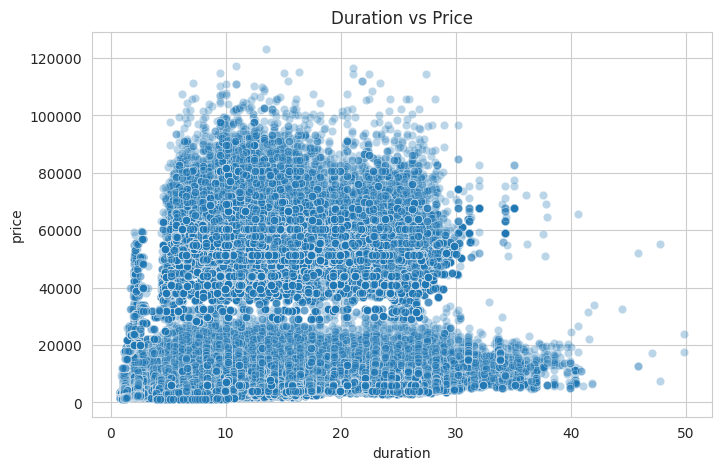

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="duration",
    y="price",
    alpha=0.3
)

plt.title("Duration vs Price")

plt.show()

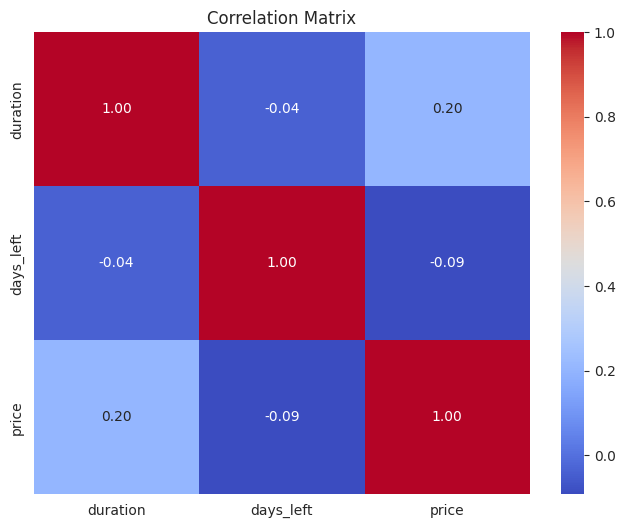

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

duration: 2110 outliers
days_left: 0 outliers
price: 123 outliers


## **Train Test Split**

In [ ]:
X = df.drop("price", axis=1)

y = df["price"]

In [ ]:
print(X.shape)
print(y.shape)

(300153, 10)
(300153,)


In [ ]:
categorical_cols = X.select_dtypes(include="object").columns

numerical_cols = X.select_dtypes(exclude="object").columns

print(categorical_cols)
print(numerical_cols)

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='object')
Index(['duration', 'days_left'], dtype='object')


In [ ]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [ ]:
X.head()

duration  days_left  airline_Air_India  airline_GO_FIRST  airline_Indigo  \
0      2.17          1              False             False           False   
1      2.33          1              False             False           False   
2      2.17          1              False             False           False   
3      2.25          1              False             False           False   
4      2.33          1              False             False           False   

   airline_SpiceJet  airline_Vistara  flight_6E-105  flight_6E-113  \
0              True            False          False          False   
1              True            False          False          False   
2             False            False          False          False   
3             False             True          False          False   
4             False             True          False          False   

   flight_6E-121  flight_6E-123  flight_6E-126  flight_6E-128  flight_6E-131  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-132  flight_6E-134  flight_6E-135  flight_6E-136  flight_6E-138  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-139  flight_6E-146  flight_6E-148  flight_6E-149  flight_6E-151  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-152  flight_6E-153  flight_6E-154  flight_6E-156  flight_6E-157  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-161  flight_6E-164  flight_6E-165  flight_6E-168  flight_6E-171  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-172  flight_6E-176  flight_6E-177  flight_6E-179  flight_6E-181  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-183  flight_6E-184  flight_6E-186  flight_6E-188  flight_6E-192  \
0          False          False          False          False          False   
1          False          False          False          False

In [ ]:
X.shape

(300153, 1590)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Columns: 1590 entries, duration to class_Economy
dtypes: bool(1588), float64(1), int64(1)
memory usage: 459.1 MB


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (240122, 1590)
X_test  : (60031, 1590)
y_train : (240122,)
y_test  : (60031,)


In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

In [ ]:
X_test.isnull().sum().sum()

np.int64(0)

In [ ]:
print(y_train.head())

148417    13524
36879      9940
274531    55983
166397     7927
272722    55502
Name: price, dtype: int64


## **Building, Evaluating & Interpreting a Decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [ ]:
dt = DecisionTreeRegressor(random_state=42)

In [ ]:
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_train_pred = dt.predict(X_train)

In [ ]:
y_test_pred = dt.predict(X_test)

In [ ]:
train_mae = mean_absolute_error(y_train, y_train_pred)

train_mse = mean_squared_error(y_train, y_train_pred)

train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training Performance")
print("--------------------")
print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

Training Performance
--------------------
MAE : 11.837750532368268
MSE : 52732.817387966665
RMSE: 229.63627193448048
R²  : 0.9998976286585489


In [ ]:
print("Train R² :", train_r2)

print("Test R²  :", test_r2)

Train R² : 0.9998976286585489
Test R²  : 0.9824004814358758


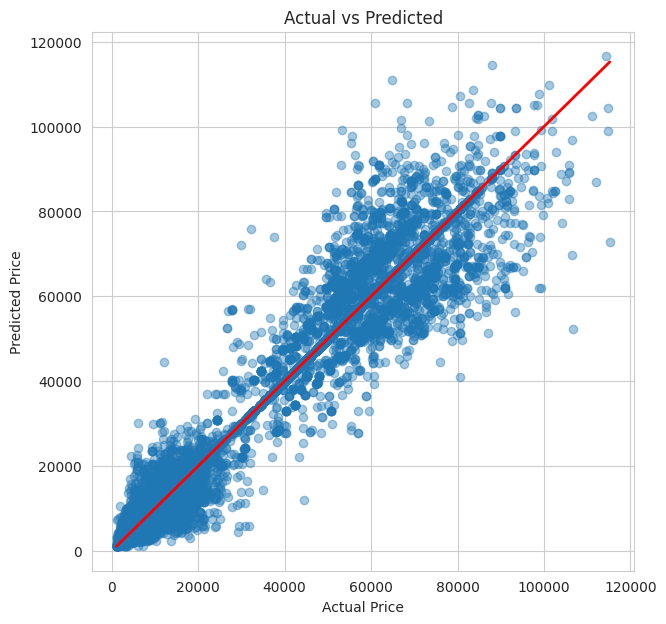

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

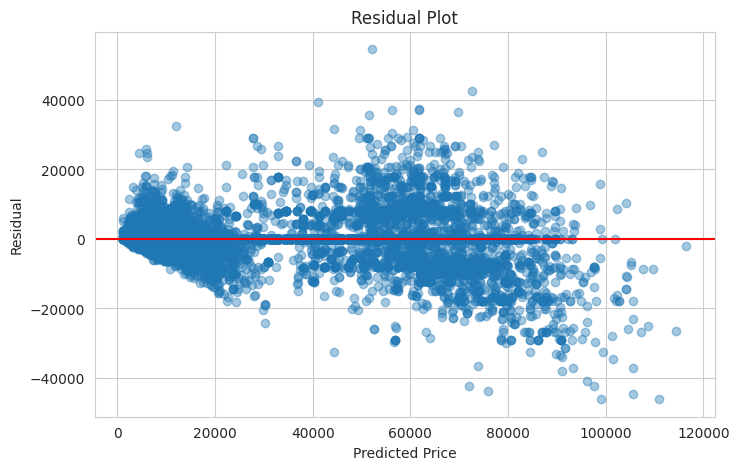

In [ ]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8,5))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    0,
    color="red"
)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

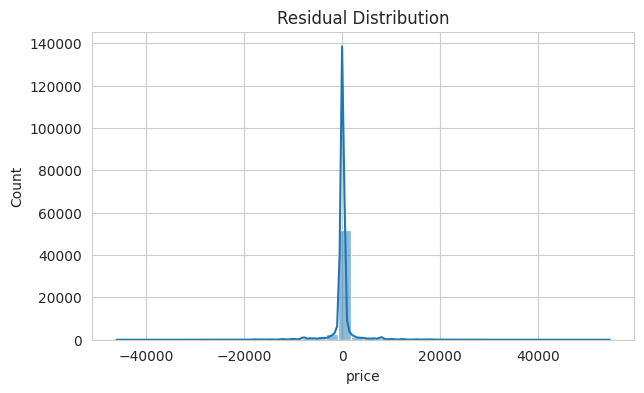

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,4))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": dt.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1589,class_Economy,0.879562
0,duration,0.048056
1,days_left,0.018064
6,airline_Vistara,0.009540
1585,destination_city_Delhi,0.004041
1568,source_city_Delhi,0.003688
1571,source_city_Mumbai,0.002336
1588,destination_city_Mumbai,0.002098
1586,destination_city_Hyderabad,0.001964
1570,source_city_Kolkata,0.001692


In [ ]:
print("Tree Depth :", dt.get_depth())

print("Number of Leaves :", dt.get_n_leaves())

Tree Depth : 96
Number of Leaves : 81328


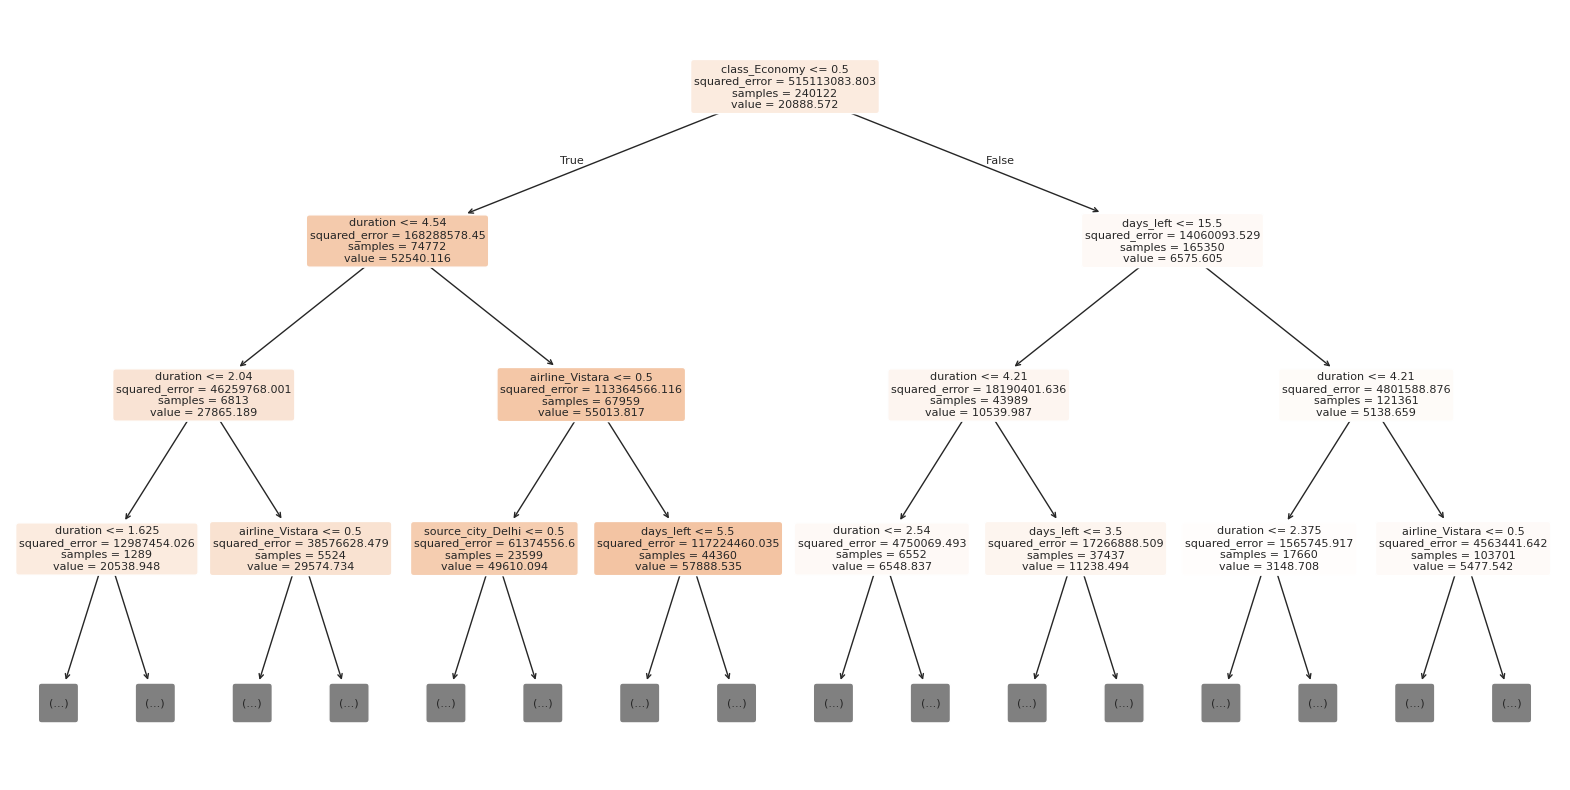

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    max_depth=3,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [ ]:
sample = X_test.iloc[[0]]

prediction = dt.predict(sample)

print("Predicted Price:", prediction[0])

print("Actual Price:", y_test.iloc[0])

Predicted Price: 7366.0
Actual Price: 7366


In [ ]:
import joblib

joblib.dump(dt, "flight_price_decision_tree_regressor.pkl")

['flight_price_decision_tree_regressor.pkl']

In [ ]:
model = joblib.load("flight_price_decision_tree_regressor.pkl")

## **Hyperparameter Tuning & Pruning**

In [ ]:
DecisionTreeRegressor(random_state=42)

DecisionTreeRegressor(random_state=42)

In [ ]:
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.tree import DecisionTreeRegressor

In [ ]:
dt1 = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt1.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
param_grid = {

    "max_depth": [5, 10, 15, 20, None],

    "min_samples_split": [2, 5, 10, 20],

    "min_samples_leaf": [1, 2, 5, 10],

    "max_features": [
        None,
        "sqrt",
        "log2"
    ]
}

In [ ]:
grid = GridSearchCV(

    estimator=DecisionTreeRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1,

    verbose=2
)